# Exploratory analysis - 363 days of YouTube listening

Everything here reads from `data/taste.db`, built by
`python -m taste_engine.parse_takeout`. Nothing in this notebook calls
the YouTube API, so it costs no quota to re-run.

The questions it answers, in order:

1. What is actually in the export, and what is broken about it?
2. How concentrated is the listening?
3. Which of the watched videos are music, and how confidently do we know?
4. What structure does the library have?
5. Does the model beat the most-played baseline?

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '../src')

import pandas as pd
import matplotlib.pyplot as plt

from taste_engine.db import connect
from taste_engine import classify, score, embed, evaluate, config

plt.rcParams.update({'figure.figsize': (9, 3.4), 'axes.grid': True,
                     'grid.alpha': .25, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})
conn = connect()
print('db:', config.DB_PATH)

db: /mnt/c/Users/uditk/Projects/taste-engine/data/taste.db


## 1. What is in the export

In [2]:
counts = {t: conn.execute(f'SELECT COUNT(*) FROM {t}').fetchone()[0]
          for t in ('plays', 'playlists', 'playlist_tracks', 'library_songs')}
counts['unique videos'] = conn.execute(
    'SELECT COUNT(DISTINCT video_id) FROM plays').fetchone()[0]
counts['plays w/o channel'] = conn.execute(
    'SELECT COUNT(*) FROM plays WHERE channel IS NULL').fetchone()[0]
lo, hi = conn.execute('SELECT MIN(watched_at), MAX(watched_at) FROM plays').fetchone()
print(pd.Series(counts).to_string())
print(f'\nrange: {lo[:10]} -> {hi[:10]}')

plays                40619
playlists               58
playlist_tracks      11475
library_songs          239
unique videos        30440
plays w/o channel     6649

range: 2025-09-14 -> 2026-09-13


### The 12-month wall

Auto-delete is on, so the history starts abruptly on 2025-09-14 and this
dataset will never grow backwards. Any 'listening over time' chart has a
hard left edge that is an artefact of Google's retention policy, not of
the user's behaviour.

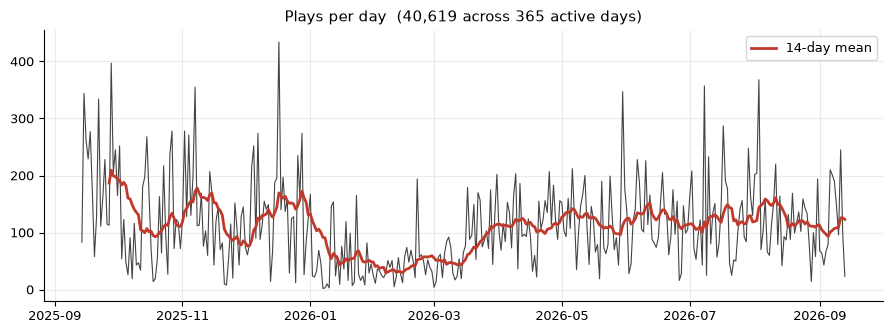

In [3]:
plays = pd.read_sql('SELECT video_id, watched_at, source FROM plays', conn)
plays['day'] = pd.to_datetime(plays.watched_at, format='ISO8601', utc=True).dt.date
daily = plays.groupby('day').size()

ax = daily.plot(lw=.8, color='#444')
daily.rolling(14).mean().plot(ax=ax, lw=2, color='#c0392b', label='14-day mean')
ax.set_title(f'Plays per day  ({daily.sum():,} across {len(daily)} active days)')
ax.set_xlabel(''); ax.legend(); plt.tight_layout(); plt.show()

### Playlist timestamps are not a signal

53 of 58 playlists claim to have been created on one of two days in March
2026 - a bulk import, not user behaviour - and the export restamped almost
every `updated_at` to the export date. Playlist recency is therefore
unusable, which is asserted in `tests/test_dataset_facts.py` so nothing
downstream starts relying on it.

Playlist titles are pseudonymised (`Playlist A`, `Playlist B`, ...) before
they reach any output in this notebook. Every metric that uses them treats
them as opaque group labels, so the real names add nothing to the analysis
and this repo is public. Track, artist and cluster names are the substance
and are shown as-is. The mapping is written to `data/playlist_aliases.json`,
which is gitignored. See `taste_engine/redact.py`.

In [4]:
from taste_engine import redact
pl = pd.read_sql('SELECT title, created_at, updated_at FROM playlists', conn)
pl['label'] = redact.redact_series(pl.title, redact.aliases_for(conn))

print('created_at:'); print(pl.created_at.str[:10].value_counts().to_string())
print('\nupdated_at:'); print(pl.updated_at.str[:10].value_counts().head(3).to_string())
dupes = pl.label.value_counts()
print(f'\nduplicate playlist titles: {(dupes > 1).sum()} '
      f'(e.g. {dupes.index[0]} x{dupes.iloc[0]})')

created_at:
created_at
2026-03-11    39
2026-03-17    14
2026-09-13     2
2026-08-18     1
2026-03-07     1
2022-09-15     1

updated_at:
updated_at
2026-09-13    56
2026-08-18     1
2026-08-11     1

duplicate playlist titles: 9 (e.g. Playlist M x3)


## 2. How concentrated is the listening?

3,570 music tracks, 10,539 plays
  top  20 tracks =  8.8% of plays
  top  50 tracks = 16.0% of plays
  top 100 tracks = 25.2% of plays
  top 500 tracks = 57.8% of plays
  played exactly once: 63.5% of tracks


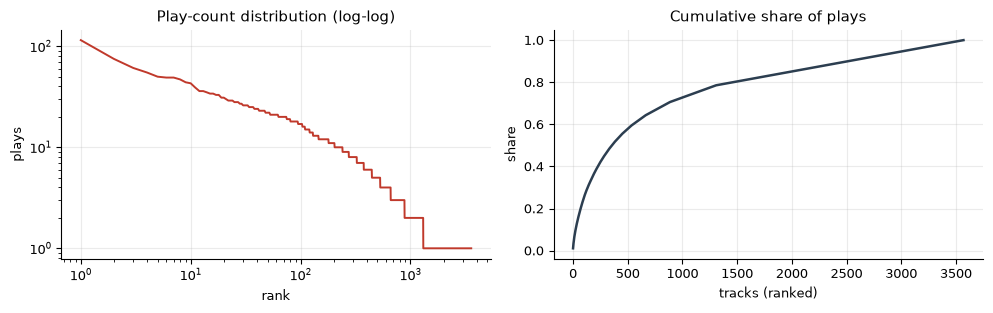

In [5]:
tracks = score.scored_tracks(conn)
pc = tracks.play_count.sort_values(ascending=False).reset_index(drop=True)
print(f'{len(pc):,} music tracks, {pc.sum():,} plays')
for n in (20, 50, 100, 500):
    print(f'  top {n:>3} tracks = {pc.head(n).sum() / pc.sum():>5.1%} of plays')
print(f'  played exactly once: {(pc == 1).mean():.1%} of tracks')

fig, (a, b) = plt.subplots(1, 2, figsize=(10, 3.2))
a.loglog(range(1, len(pc) + 1), pc.values, lw=1.4, color='#c0392b')
a.set(title='Play-count distribution (log-log)', xlabel='rank', ylabel='plays')
b.plot(pc.cumsum().values / pc.sum(), lw=1.8, color='#2c3e50')
b.set(title='Cumulative share of plays', xlabel='tracks (ranked)', ylabel='share')
plt.tight_layout(); plt.show()

A 60% one-play rate is why `log1p` matters. Raw counts would let a handful
of obsessively repeated tracks dominate every playlist; `log1p` keeps the
gap meaningful without letting it crush the tail.

## 3. Which videos are music?

Five signals, none of which costs API quota. The union is the training set.

                     signal  videos  plays  pct_videos  pct_plays
Channel ends with '- Topic'    2336   6387         7.7       15.7
    Channel contains 'VEVO'     371   2225         1.2        5.5
Played on music.youtube.com    2472   7342         8.1       18.1
Video appears in a playlist     845   3549         2.8        8.7
  Video in YT Music library     134   1055         0.4        2.6
         Union (any signal)    2858   9134         9.4       22.5


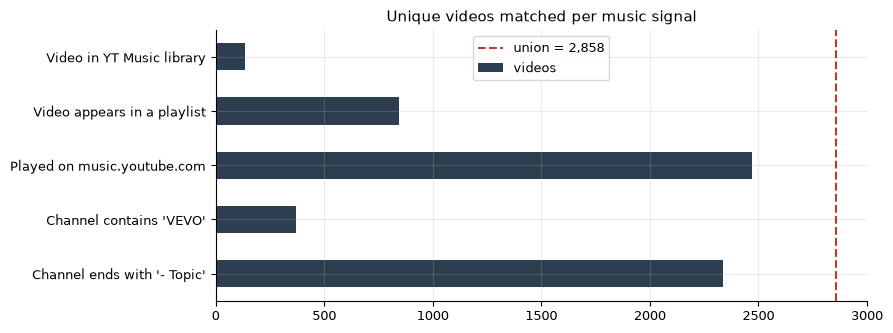

In [6]:
cov = classify.signal_coverage(conn)
print(cov.to_string(index=False))

ax = cov.iloc[:-1].plot.barh(x='signal', y='videos', legend=False,
                             color='#2c3e50')
ax.axvline(cov.videos.iloc[-1], color='#c0392b', ls='--',
           label=f'union = {cov.videos.iloc[-1]:,}')
ax.set(title='Unique videos matched per music signal', ylabel='')
ax.legend(); plt.tight_layout(); plt.show()

The signals overlap heavily: they sum to 6,158 but the union is only 2,858.
They also share a blind spot - an artist-owned channel with no `- Topic` or
`VEVO` marker is invisible to all five. `videos.list` fixes that for 609
units; see `taste_engine.resolve`.

In [7]:
if classify.has_metadata(conn):
    t = classify.comparison_table(conn)
    print(f"agreement   {t['agreement_rate']:.1%}")
    print(f"precision   {t['heuristic_precision']:.1%}")
    print(f"recall      {t['heuristic_recall']:.1%}")
    print(t['confusion'])
else:
    print('No API metadata cached - heuristic labels only.')
    print('Run: python -m taste_engine.resolve   (609 units)')

agreement   97.3%
precision   98.1%
recall      79.7%
{'both_music': 2798, 'api_only': 712, 'heuristic_only': 53, 'neither': 24570}


## 4. What structure does the library have?

In [8]:
clustered = embed.cluster_tracks(tracks)
summary = embed.cluster_summary(clustered)
n = int(clustered.loc[clustered.cluster >= 0, 'cluster'].nunique())
noise = (clustered.cluster == -1).mean()
print(f'{n} clusters, {noise:.1%} outliers')
summary[summary.cluster >= 0].head(15)

45 clusters, 44.1% outliers


,cluster,name,tracks,plays,mean_score,top_track
0,44,Lil Peep,9,69,1.254,Lil Peep - nuts (feat. rainy bear) (Official
1,43,Lil Baby,32,120,0.308,Ready
2,42,Lil Peep,10,27,0.595,haunt u
3,41,Kendrick Lamar / Kanye West / Chris Brown,48,161,0.361,luther
4,40,Drake,119,506,0.479,Drake - Janice STFU
5,39,Travis Scott,145,1028,0.676,Travis Scott - MY EYES (Official Audio)
6,38,Ellie Goulding / Frank Ocean / Molly Santana,30,51,0.171,George Michael - Careless Whisper (Official
7,37,Post Malone,14,39,0.364,Post Malone - Congratulations (Official Musi
8,36,Young Thug,17,37,0.118,B*tches Gone Tell (feat. Meek Mill)
9,35,Lil Uzi Vert,15,92,0.832,20 Min


Two honest caveats.

**These are artist clusters, not moods.** The embedding text is
`"{title} - {artist}"`, so MiniLM keys heavily on the artist name. Genre
is a decent proxy for mood, but a track that sounds nothing like the rest
of an artist's catalogue still lands with them.

**~40% of tracks are outliers.** Given 60% of tracks were played exactly
once, that is closer to honest than alarming - HDBSCAN is refusing to
invent a mood for a one-off listen, which is exactly why it was chosen
over KMeans.

### Is the artist the problem? Test it, do not assume it

The obvious fix is to drop the artist and embed title plus genre. Scored
against an **external** ground truth - the user's own 48 playlists,
restricted to tracks filed in exactly one - it makes things worse.
Silhouette would measure tidiness in the space the clustering was built
from, which is circular; a human saying 'these belong together' is not.

In [9]:
from taste_engine import cluster_eval
cluster_eval.compare_modes(conn, tracks)

,mode,status,n_eval,coverage,ari,nmi,purity,clusters,noise
0,title_artist,ok,256,0.526749,0.626697,0.626945,0.667969,45,0.441176
1,title,ok,119,0.244856,0.179554,0.611093,0.563025,51,0.696919
2,title_genre,ok,327,0.672840,0.396936,0.458105,0.437309,33,0.411204


Bare titles (`TBH`, `20 Min`, `Ready`) carry almost no semantic signal, so
noise jumps and coverage collapses. Genre tags do help coverage - there
are only 35 distinct ones, so the buckets are broad and cut across the
finer distinctions the user actually drew. `coverage` is reported so a
clustering cannot win by calling everything noise.

Caveat: the ground truth is itself partly artist-shaped - several
playlists are single-artist collections - so it rewards artist clustering
to some degree by construction.

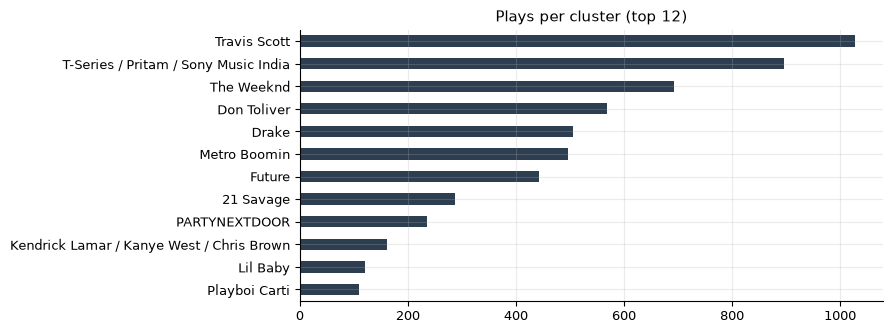

In [10]:
top = summary[summary.cluster >= 0].nlargest(12, 'plays')
ax = top.plot.barh(x='name', y='plays', legend=False, color='#2c3e50')
ax.set(title='Plays per cluster (top 12)', ylabel='')
ax.invert_yaxis(); plt.tight_layout(); plt.show()

## 5. Does it beat the baseline?

Temporal hold-out: train strictly before the split, test after. The model
sees no test-window play - not for scoring, not for clustering.

### Rediscovery - the task that matters

Remove the training window's 50 most-played tracks from both the
candidate pool and the ground truth, then ask what else gets played.
'Name the tracks he plays most' *is* the baseline; a model that agrees
with it has not recommended anything.

In [11]:
redis = evaluate.evaluate_rediscovery(conn, k=20,
                                      test_days=config.EVAL_TEST_DAYS)
print(f"candidates {redis['candidates']:,} | reachable truth "
      f"{redis['reachable']:,} | ceiling@20 {redis['ceiling']:.1%}")
redis['results']

candidates 2,410 | reachable truth 458 | ceiling@20 4.4%


,strategy,hits,recall@20,precision@20,ndcg@20
2,recency,13,0.0284,0.65,0.3200
1,score,20,0.0437,1.00,0.2749
0,most_played,13,0.0284,0.65,0.2024
3,cluster_diverse,16,0.0349,0.80,0.1941


`recall@20` is capped at the ceiling printed above - 20 picks against
hundreds of reachable tracks - so it is for comparing strategies, not a
headline. Note `hits` and `ndcg` can disagree: nDCG is graded by how many
times a track was actually replayed, so a few heavy-rotation finds beat
many marginal ones.

In [12]:
detail, summary_r = evaluate.rediscovery_robustness(
    conn, k=20, test_days=config.EVAL_TEST_DAYS)
summary_r

,strategy,mean_ndcg@20,mean_recall@20,beats_baseline,splits
1,score,0.3725,0.049150,3,4
0,most_played,0.3457,0.042175,0,4
3,cluster_diverse,0.2880,0.043700,1,4
2,recency,0.1680,0.032300,1,4


### Replay - the trivial task, shown for contrast

Rank the whole catalogue by what gets played next. Run as originally
specified (precision@20, full 105-day window) the **baseline scores
1.00** - a track played 50 times in nine months is certain to recur in
the next three. A metric that cannot go up cannot rank anything.

In [13]:
sat = evaluate.evaluate(conn, k=20, test_days=None)
print(f"precision@20, full 105-day window - saturated: {sat['saturated']}")
sat['results'][['strategy', 'hits', 'precision@20', 'ndcg@20']]

precision@20, full 105-day window - saturated: True


,strategy,hits,precision@20,ndcg@20
0,most_played,20,1.0,0.5784
1,score,20,1.0,0.5284
3,cluster_diverse,20,1.0,0.3822
2,recency,16,0.8,0.3327


Shortening the horizon and raising k restores discrimination - and on
this task the baseline is genuinely competitive, which is the point.

In [14]:
report = evaluate.evaluate(conn, test_days=config.EVAL_TEST_DAYS)
print(f"train < {report['split_date']} <= test ({report['test_days']}d), "
      f"k={report['k']}, half-life={report['half_life']:.0f}d")
report['results']

train < 2026-06-01 <= test (30d), k=50, half-life=14d


,strategy,hits,precision@50,ndcg@50,spearman
1,score,48,0.96,0.5661,0.4044
0,most_played,43,0.86,0.5480,0.4788
3,cluster_diverse,32,0.64,0.3277,NaN
2,recency,23,0.46,0.3073,0.3058


### The result that does not flatter the model

Over the *whole* catalogue, raw play count correlates better with future
play volume than the recency-weighted score does - see the `spearman`
column above. Recency helps at the head of the list, which is what a
playlist draws from, and hurts in the tail. Both are true and both are
reported.

In [15]:
conn.close()
print('done')

done
